# AMSR2/AMSR-E Data Access
This tutorial is designed to access snow water equivalent (SWE) data from the Advanced Microwave Scanning Radiometer missions (AMSR2/-E).

In [1]:
import earthaccess
import geopandas as gpd
import glob
import xarray as xr
import rioxarray as rxr
import matplotlib.pyplot as plt
import h5py
import numpy as np
import datetime

The AMSR SWE data is available through NSIDC, so we are capable of streaming it directly through the cloud. Let's start with a simple example using only a single file.

According to its NSIDC webpage (https://nsidc.org/data/au_dysno/versions/1), the short name for the AMSR SWE product is `AU_DySno`. We will look at an image that includes Fairbanks, AK during the SnowEx campaign in March 2023.

In [2]:
# Authenticate with earthaccess
earthaccess.login()

In [3]:
# Convert Fairbanks geoJSON to earthaccess-friendly format.
fairbanks = gpd.read_file("/home/jovyan/snow-observations-cookbook/notebooks/data/cffl_lidar_box.geojson")
fairbanks.to_crs("EPSG:4326", inplace=True)
minx, miny, maxx, maxy = fairbanks.total_bounds

# Run the earthaccess query
results = earthaccess.search_data(
    short_name='AU_DySno',
    bounding_box=(minx, miny, maxx, maxy),
    temporal=("2023-03-01", "2023-03-31"),
    count=10
)

In [5]:
display(results[0])

Collection: {'EntryTitle': 'AMSR-E/AMSR2 Unified L3 Global Daily 25 km EASE-Grid Snow Water Equivalent V001'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'BoundingRectangles': [{'WestBoundingCoordinate': -180.0, 'EastBoundingCoordinate': 180.0, 'NorthBoundingCoordinate': 89.24, 'SouthBoundingCoordinate': -89.24}]}}}
Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2023-02-28T00:34:25.994Z', 'EndingDateTime': '2023-03-01T00:28:07.264Z'}}
Size(MB): 9.97532
Data: ['https://data.nsidc.earthdatacloud.nasa.gov/nsidc-cumulus-prod-protected/AMSA/AU_DySno/1/2023/02/28/AMSR_U2_L3_DailySnow_B02_20230228.he5', 'https://data.nsidc.earthdatacloud.nasa.gov/nsidc-cumulus-prod-protected/AMSA/AU_DySno/1/2023/02/28/AMSR_U2_L3_DailySnow_B02_20230228.ph']

In [4]:
# Stream the data directly into memory
files = earthaccess.open(results)

QUEUEING TASKS | :   0%|          | 0/20 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/20 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/20 [00:00<?, ?it/s]

In [5]:
files

[<File-like object S3FileSystem, nsidc-cumulus-prod-protected/AMSA/AU_DySno/1/2023/02/28/AMSR_U2_L3_DailySnow_B02_20230228.he5>,
 <File-like object S3FileSystem, nsidc-cumulus-prod-protected/AMSA/AU_DySno/1/2023/02/28/AMSR_U2_L3_DailySnow_B02_20230228.ph>,
 <File-like object S3FileSystem, nsidc-cumulus-prod-protected/AMSA/AU_DySno/1/2023/03/01/AMSR_U2_L3_DailySnow_B02_20230301.he5>,
 <File-like object S3FileSystem, nsidc-cumulus-prod-protected/AMSA/AU_DySno/1/2023/03/01/AMSR_U2_L3_DailySnow_B02_20230301.ph>,
 <File-like object S3FileSystem, nsidc-cumulus-prod-protected/AMSA/AU_DySno/1/2023/03/02/AMSR_U2_L3_DailySnow_B02_20230302.he5>,
 <File-like object S3FileSystem, nsidc-cumulus-prod-protected/AMSA/AU_DySno/1/2023/03/02/AMSR_U2_L3_DailySnow_B02_20230302.ph>,
 <File-like object S3FileSystem, nsidc-cumulus-prod-protected/AMSA/AU_DySno/1/2023/03/03/AMSR_U2_L3_DailySnow_B02_20230303.he5>,
 <File-like object S3FileSystem, nsidc-cumulus-prod-protected/AMSA/AU_DySno/1/2023/03/03/AMSR_U2_L3_

In [6]:
dom_ref = rxr.open_rasterio(files[0])

/srv/conda/envs/notebook/lib/python3.12/site-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/srv/conda/envs/notebook/lib/python3.12/site-packages/rioxarray/_io.py:1143: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  warnings.warn(str(rio_warning.message), type(rio_warning.message))  # type: ignore
/srv/conda/envs/notebook/lib/python3.12/site-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/srv/conda/envs/notebook/lib/python3.12/site-packages/rioxarray/_io.py:1143: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  warnings.warn(str(rio_w

In [44]:
with h5py.File(files[0], 'r') as f:
    # Read the datasets
    lon = f['HDFEOS/GRIDS/Northern Hemisphere/lon'][:]
    lat = f['HDFEOS/GRIDS/Northern Hemisphere/lat'][:]
    swe = f['HDFEOS/GRIDS/Northern Hemisphere/Data Fields/SWE_NorthernDaily'][:]

# Create masks for valid coordinates
valid_mask = np.isfinite(lon) & np.isfinite(lat)

# Apply mask to coordinates - replace non-finite with a dummy value
# or create a version with only finite values
lon_clean = np.where(np.isfinite(lon), lon, 0)
lat_clean = np.where(np.isfinite(lat), lat, 0)

# Mask SWE data where coordinates are invalid
swe_masked = np.where(valid_mask, swe, np.nan)
#swe_masked = np.where((swe_masked<250)&(swe_masked>0), swe_masked, np.nan)

/tmp/ipykernel_238/304762487.py:2: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im = ax.pcolormesh(lon_clean, lat_clean, swe_masked)


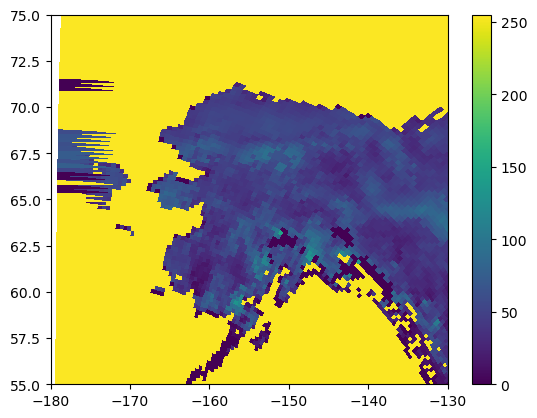

In [45]:
ax = plt.axes()
im = ax.pcolormesh(lon_clean, lat_clean, swe_masked)
ax.set_xlim(-180, -130)
ax.set_ylim(55, 75)
plt.colorbar(im, ax=ax)

In [29]:
np.nanmax(swe_masked)

255.0

In [89]:
def assign_and_grid(ds, file):
    with h5py.File(files[0],'r') as f:
        x = f['HDFEOS']['GRIDS']['Northern Hemisphere']['lon'][:] # X-coordinates
        y = f['HDFEOS']['GRIDS']['Northern Hemisphere']['lat'][:] # Y-coordinates
        data = f['HDFEOS']['GRIDS']['Northern Hemisphere']['Data Fields']['SWE_NorthernDaily'][:] # Snow cover

    # Create coordinate arrays (adjust if you need a specific dimension order)
    coords = {'x': x, 'y': y}

    # Create the xarray dataset
    ds = xr.DataArray(data, coords=coords, dims=['y', 'x'])
    # If you need to create a full Dataset (not just a DataArray), you can do:
    ds = ds.to_dataset(name='SWE_NorthernDaily')
    ds = ds.rio.write_crs("EPSG:3408")
    return ds

In [93]:
with h5py.File(files[0],'r') as f:
    lon = f['HDFEOS']['GRIDS']['Northern Hemisphere']['lon'][:]
    lat = f['HDFEOS']['GRIDS']['Northern Hemisphere']['lat'][:]
    data = f['HDFEOS']['GRIDS']['Northern Hemisphere']['Data Fields']['SWE_NorthernDaily'][:]

# Extract 1D coordinates
x = lon[0, :]  # or np.unique(lon) if it's truly regular
x = x[np.isfinite(x)]
y = lat[:, 0]  # or np.unique(lat) if it's truly regular
y = y[np.isfinite(y)]

# Create DataArray with actual lat/lon as dimensions
ds = xr.DataArray(data, coords={'y': y, 'x': x}, dims=['y', 'x'])
ds = ds.to_dataset(name='SWE_NorthernDaily')
ds = ds.rio.write_crs("EPSG:4326")

array([-135.15959, -135.23973, -135.32008, -135.40067, -135.48146,
       -135.5625 , -135.64375, -135.72522, -135.80693, -135.88885,
       -135.97102, -136.0534 , -136.13603, -136.21887, -136.30196,
       -136.38525, -136.4688 , -136.55257, -136.63658, -136.72081,
       -136.80528, -136.89   , -136.97493, -137.0601 , -137.14552,
       -137.23117, -137.31706, -137.40318, -137.48955, -137.57616,
       -137.663  , -137.75009, -137.83742, -137.92497, -138.01279,
       -138.10085, -138.18913, -138.27768, -138.36646, -138.45549,
       -138.54477, -138.6343 , -138.72406, -138.81407, -138.90434,
       -138.99486, -139.08562, -139.17664, -139.2679 , -139.3594 ,
       -139.45117, -139.5432 , -139.63547, -139.72798, -139.82077,
       -139.9138 , -140.00708, -140.10063, -140.19443, -140.28848,
       -140.3828 , -140.47737, -140.5722 , -140.66728, -140.76263,
       -140.85825, -140.9541 , -141.05023, -141.14662, -141.24327,
       -141.3402 , -141.43736, -141.5348 , -141.6325 , -141.73

In [90]:
ds = xr.open_dataset(files[0])
ds = assign_and_grid(ds, files[0])

MissingDimensionsError: cannot set variable 'x' with 2-dimensional data without explicit dimension names. Pass a tuple of (dims, data) instead.

ValueError: x and y arguments to pcolormesh cannot have non-finite values or be of type numpy.ma.MaskedArray with masked values

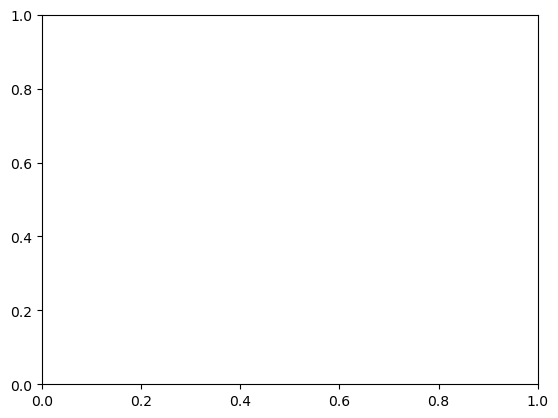

In [75]:
ds = ds.assign_coords(x=ds.x.where(np.isfinite(ds.x)))
ds = ds.assign_coords(y=ds.y.where(np.isfinite(ds.y)))
ds = ds.dropna(dim='x')
ds = ds.dropna(dim='y')

ds['SWE_NorthernDaily'].plot()

In [70]:
ds = ds.assign_coords(x=ds.x.where(np.isfinite(ds.x)), drop=True)

In [76]:
ds

<xarray.Dataset> Size: 9MB
Dimensions:            (y: 721, x: 721)
Coordinates:
    y                  (y, x) float32 2MB nan nan -84.42 ... -84.42 nan nan
    x                  (y, x) float32 2MB nan nan -135.2 ... 44.84 nan nan
    lon                (y, x) float32 2MB nan nan -135.2 ... 44.84 nan nan
    lat                (y, x) float32 2MB nan nan -84.42 ... -84.42 nan nan
    spatial_ref        int64 8B 0
Data variables:
    SWE_NorthernDaily  (y, x) uint8 520kB 248 248 248 248 ... 248 248 248 248